<a href="https://colab.research.google.com/github/cesarjuarez72/p2_cesar_juarez_data_clean_prep_stock_market_data/blob/main/ai_p2_stockmkt_data_clean_prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1 — Clean and Prepare the Data

### What We Are Doing
Before we can calculate moving averages or teach a machine learning model how stocks behave, our data has to be orderly. In this section, we take the raw market records and set them up for time-series engineering:
1. Load both the price history and the company catalog.
2. Turn the date strings into real calendar timestamps (`datetime64[ns]`).
3. Sort the price records first by **ticker**, and then chronologically by **date**. (This step is critical: when we calculate yesterday's price or a 20-day trend, each stock must be in strict time order).
4. Remove the accidental header row (`['Symbol', 'NYSE', ...]`) at index 74 that slipped into the company master list during an upstream merge.
5. Review the extreme numbers we uncovered during Project 1 and decide how to treat them before building features.

---

### Decisions on Unusual Values from Project 1

* **Multi-Million-Dollar Closes (e.g., SCON, CODA, TOPS):**  
  * **What they are:** In Project 1, we found stocks showing raw prices over 1,000,000 USD on tiny trading volumes (fewer than 400 shares). These are **not typos**. They happen because struggling penny stocks perform repeated reverse splits (like 1-for-50) to stay listed on the exchange. When a data provider calculates backwards, pre-split prices multiply into giant numbers.
  * **Our Decision:** **Retain them.** They represent legitimate historical corporate restructuring, not corrupted data. However, because their massive scale can distort standard price predictions, our downstream feature engineering will focus on percentage returns and normalized indicators rather than raw dollar prices.

* **The 18.9 Quintillion USD Glitch (Ticker: AAN):**  
  * **What it is:** On February 27, 1987, Aaron's, Inc. (`AAN`) traded normally at 1.30 USD. But its adjusted close column (`adj_close`) blew up to 18,949,618,910,812,438,528.00 USD due to an upstream divide-by-zero or missing split divisor bug.
  * **Our Decision:** **Retain the trading record, but drop or exclude `adj_close` from modeling.** The company's raw open, high, low, close, and volume are 100% accurate. Because Project 2 builds features directly from raw closing prices (`close`) and volume, we do not throw out the trading day—we simply keep the corrupted `adj_close` column out of our final machine learning feature set.

In [ ]:
import pandas as pd
import numpy as np
import os
from google.colab import drive

print("=" * 60)
print("PART 1: MOUNTING DRIVE, LOADING, AND PREPARING DATA")
print("=" * 60)

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Locate CSV files in Drive
# Default check: adjust subfolder if stored inside a specific Drive folder
prices_filename = "historical_stock_prices.csv"
stocks_filename = "historical_stocks.csv"

# Quick scan in Drive to find the exact file paths automatically
prices_path = None
stocks_path = None

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if prices_filename in files and prices_path is None:
        prices_path = os.path.join(root, prices_filename)
    if stocks_filename in files and stocks_path is None:
        stocks_path = os.path.join(root, stocks_filename)
    if prices_path and stocks_path:
        break

# Fallback to direct path if scan doesn't catch them
if not prices_path:
    prices_path = f"/content/drive/MyDrive/{prices_filename}"
if not stocks_path:
    stocks_path = f"/content/drive/MyDrive/{stocks_filename}"

print(f"Loading prices from: {prices_path}")
print(f"Loading stocks from: {stocks_path}")

# 3. Read raw CSV datasets
df_prices = pd.read_csv(prices_path)
df_stocks = pd.read_csv(stocks_path)

print(f"Loaded df_prices: {len(df_prices):,} rows, {len(df_prices.columns)} columns")
print(f"Loaded df_stocks: {len(df_stocks):,} rows, {len(df_stocks.columns)} columns")

# 4. Purge row 74 artifact from df_stocks
row_74_check = df_stocks.loc[74, 'ticker'] if 74 in df_stocks.index else None
if row_74_check == 'Symbol':
    df_stocks = df_stocks.drop(index=74).reset_index(drop=True)
    print("Purged corrupted row 74 from df_stocks successfully.")
else:
    print(f"Row 74 status: ticker is '{row_74_check}' (verified clean).")

# Impute missing sector and industry for ETFs, trusts, and SPACs
df_stocks['sector'] = df_stocks['sector'].fillna('Unknown')
df_stocks['industry'] = df_stocks['industry'].fillna('Unknown')
print("Imputed missing sectors/industries with 'Unknown'.")

# 5. Convert date to datetime format
df_prices['date'] = pd.to_datetime(df_prices['date'])
print("Converted df_prices['date'] to datetime64[ns].")

# 6. Sort strictly by ticker and chronological date
print("Sorting df_prices by ['ticker', 'date']...")
df_prices = df_prices.sort_values(by=['ticker', 'date']).reset_index(drop=True)

# 7. Quick validation check
print("\nValidation Summary:")
print(f"- Total Clean Stocks : {len(df_stocks):,} unique listings")
print(f"- Total Price Records: {len(df_prices):,} rows")
print(f"- Date Boundaries    : {df_prices['date'].min().strftime('%Y-%m-%d')} to {df_prices['date'].max().strftime('%Y-%m-%d')}")
print(f"- Memory Usage (GB)  : {df_prices.memory_usage().sum() / 1e9:.2f} GB")

# Show top 5 sorted rows
print("\nFirst 5 rows sorted by ticker and date:")
display(df_prices.head())

PART 1: MOUNTING DRIVE, LOADING, AND PREPARING DATA
Mounted at /content/drive
Loading prices from: /content/drive/MyDrive/StockData/historical_stock_prices.csv
Loading stocks from: /content/drive/MyDrive/StockData/historical_stocks.csv
Loaded df_prices: 20,973,889 rows, 8 columns
Loaded df_stocks: 6,460 rows, 5 columns
Purged corrupted row 74 from df_stocks successfully.
Imputed missing sectors/industries with 'Unknown'.
Converted df_prices['date'] to datetime64[ns].
Sorting df_prices by ['ticker', 'date']...

Validation Summary:
- Total Clean Stocks : 6,459 unique listings
- Total Price Records: 20,973,889 rows
- Date Boundaries    : 1970-01-02 to 2018-08-24
- Memory Usage (GB)  : 1.34 GB

First 5 rows sorted by ticker and date:


,ticker,open,close,adj_close,low,high,volume,date
0,A,32.546494,31.473534,27.494957,28.612303,35.765381,62546300,1999-11-18
1,A,30.713520,28.880543,25.229753,28.478184,30.758226,15234100,1999-11-19
2,A,29.551144,31.473534,27.494957,28.657009,31.473534,6577800,1999-11-22
3,A,30.400572,28.612303,24.995413,28.612303,31.205294,5975600,1999-11-23
4,A,28.701717,29.372318,25.659359,28.612303,29.998211,4843200,1999-11-24


# Part 2 — Create Useful Features

### What We Are Doing
Raw stock prices (open, high, low, close) only tell us where a stock stood at a single moment in time. Machine learning models need context: Is the stock trending up? Did yesterday's price collapse? Is it swinging wildly or trading calmly?

In this section, we engineer time-series features that capture price momentum, trend baselines, and market volatility.

**Engineering Rule:** Because our table contains 6,459 different companies stacked together, all rolling windows, lags, and percentage changes are computed strictly **grouped by ticker**. This guarantees that Stock B never accidentally inherits rolling data from the end of Stock A.

---

### Features Created

1. **`close_lag_1` (Previous-Day Close):** The closing price from the previous trading session (`close.shift(1)`).
2. **`price_change` (Absolute Dollar Change):** Today's closing price minus yesterday's closing price (`close - close_lag_1`).
3. **`daily_return` (Percentage Return):** The proportional price change from yesterday (`close.pct_change(1)`). A value of `0.02` means a 2% gain; `-0.015` means a 1.5% loss.
4. **`ma_5` (5-Day Moving Average):** The average closing price over the past 5 trading days (captures short-term, 1-week momentum).
5. **`ma_20` (20-Day Moving Average):** The average closing price over the past 20 trading days (captures medium-term, ~1-month trend).
6. **`volatility_20` (20-Day Rolling Volatility):** The 20-day rolling standard deviation of `daily_return`.
7. **`daily_range_pct` (Intraday High-Low Spread Percentage):**  
   $$\frac{\text{high} - \text{low}}{\text{low}}$$  
   *Why we chose it:* Closing prices can hide major intraday battles. A stock might open at 20 USD, spike to 25 USD, sink to 18 USD, and close at 20 USD (showing zero net dollar change). `daily_range_pct` captures this intraday turbulence directly, providing a clean indicator of trading uncertainty.

---

### Direct Answers to Assignment Questions

1. **What does `daily_return` tell us?**  
   It tells us the proportional gain or loss an investor experienced from one trading day to the next, normalized across all price levels. A 1.00 USD gain on a 5.00 USD stock (+20%) is drastically different from a 1.00 USD gain on a 500.00 USD stock (+0.2%). `daily_return` puts every stock on equal footing regardless of whether its share price is 2 USD or 2,000 USD.

2. **What does a moving average tell us about a stock?**  
   It smooths out daily market noise to expose the underlying price trend. If today's price sits comfortably above its 20-day moving average (`close > ma_20`), the stock is in a short-to-medium-term uptrend. If the 5-day average crosses below the 20-day average, it signals weakening momentum.

3. **What does high volatility indicate?**  
   High volatility means prices are swinging unpredictably in wide swings (large gains and steep drops within short windows). It signals elevated risk, heightened market uncertainty, or major news events (earnings reports, regulatory scrutiny, macroeconomic shocks).

4. **Why do lag and rolling features create missing values at the beginning of each stock's history?**  
   Because time-series math requires historical lookbacks:
   * A 1-day lag requires at least 1 prior day. (Day 1 has no yesterday $\rightarrow$ 1 `NaN`).
   * A 5-day moving average requires a window of 5 completed days (Days 1–4 lack sufficient history $\rightarrow$ 4 `NaN`s).
   * A 20-day rolling metric requires 20 consecutive sessions (Days 1–19 lack sufficient history $\rightarrow$ 19 `NaN`s).  
   Every single stock needs a "warm-up" period before rolling indicators can calculate.

In [ ]:
print("=" * 60)
print("PART 2: VECTORIZED FEATURE ENGINEERING (BY TICKER)")
print("=" * 60)

# Ensure data remains sorted chronologically by ticker
df_prices = df_prices.sort_values(by=['ticker', 'date']).reset_index(drop=True)

# Group by ticker for isolated time-series calculations
grouped = df_prices.groupby('ticker')

print("Calculating 1-day lag, dollar change, and percentage return...")
df_prices['close_lag_1'] = grouped['close'].shift(1)
df_prices['price_change'] = df_prices['close'] - df_prices['close_lag_1']
df_prices['daily_return'] = grouped['close'].pct_change(1)

print("Calculating 5-day and 20-day rolling moving averages...")
df_prices['ma_5'] = grouped['close'].transform(lambda s: s.rolling(window=5).mean())
df_prices['ma_20'] = grouped['close'].transform(lambda s: s.rolling(window=20).mean())

print("Calculating 20-day rolling volatility of daily returns...")
df_prices['volatility_20'] = grouped['daily_return'].transform(lambda s: s.rolling(window=20).std())

print("Calculating selected 7th feature: daily_range_pct (Intraday Spread %)...")
df_prices['daily_range_pct'] = (df_prices['high'] - df_prices['low']) / df_prices['low']

# Quick sanity check on Apple (AAPL) to verify calculations
print("\nSanity Check: First 7 records for AAPL (showing warm-up NaNs then valid rolling numbers):")
aapl_sample = df_prices[df_prices['ticker'] == 'AAPL'][
    ['ticker', 'date', 'close', 'close_lag_1', 'price_change', 'daily_return', 'ma_5', 'ma_20', 'volatility_20', 'daily_range_pct']
].head(7)
display(aapl_sample)

print("\nEngineered Columns Summary:")
new_cols = ['close_lag_1', 'price_change', 'daily_return', 'ma_5', 'ma_20', 'volatility_20', 'daily_range_pct']
display(df_prices[new_cols].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])

PART 2: VECTORIZED FEATURE ENGINEERING (BY TICKER)
Calculating 1-day lag, dollar change, and percentage return...
Calculating 5-day and 20-day rolling moving averages...
Calculating 20-day rolling volatility of daily returns...
Calculating selected 7th feature: daily_range_pct (Intraday Spread %)...

Sanity Check: First 7 records for AAPL (showing warm-up NaNs then valid rolling numbers):


,ticker,date,close,close_lag_1,price_change,daily_return,ma_5,ma_20,volatility_20,daily_range_pct
51923,AAPL,1980-12-12,0.513393,NaN,NaN,NaN,NaN,NaN,NaN,0.004348
51924,AAPL,1980-12-15,0.486607,0.513393,-0.026786,-0.052174,NaN,NaN,NaN,0.004587
51925,AAPL,1980-12-16,0.450893,0.486607,-0.035714,-0.073394,NaN,NaN,NaN,0.004950
51926,AAPL,1980-12-17,0.462054,0.450893,0.011161,0.024752,NaN,NaN,NaN,0.004831
51927,AAPL,1980-12-18,0.475446,0.462054,0.013393,0.028986,0.477679,NaN,NaN,0.004695
51928,AAPL,1980-12-19,0.504464,0.475446,0.029018,0.061033,0.475893,NaN,NaN,0.004425
51929,AAPL,1980-12-22,0.529018,0.504464,0.024554,0.048673,0.484375,NaN,NaN,0.004219



Engineered Columns Summary:


,count,mean,std,min,50%,max
close_lag_1,20968204.0,76.113189,2870.170969,2.000000e-04,15.450000,1.779750e+06
price_change,20968204.0,-0.210589,631.488481,-1.354374e+06,0.000000,1.354374e+06
daily_return,20968204.0,0.217656,105.071795,-9.999937e-01,0.000000,1.598147e+05
ma_5,20951154.0,75.767255,2790.920453,4.000000e-04,15.454000,1.397025e+06
ma_20,20866005.0,74.749793,2646.535876,6.500000e-04,15.461500,9.022078e+05
volatility_20,20860334.0,0.647700,101.525010,0.000000e+00,0.019423,3.589016e+04
daily_range_pct,20973889.0,0.035385,0.433849,-8.894737e-01,0.023756,8.505000e+02


# Part 3 — Combine and Organize the Data

### What We Are Doing
In this section, we assemble all company details and market indicators into a unified dataset ready for machine learning:
1. **Merge Metadata:** Join our price and feature records with `df_stocks` using `ticker` as the key, adding `exchange`, `sector`, and `industry`.
2. **Handle Warm-Up Missing Values:** Address the `NaN` values created by our 1-day lags and 20-day rolling calculations.
3. **Encode Categorical Data:** Convert text labels (`exchange` and `sector`) into binary numerical columns using one-hot encoding.

---

### Decisions on Missing Values (Feature Warm-Ups)

* **Why we do NOT fill with zero:**  
  Substituting zero into `price_change`, `daily_return`, or `volatility_20` distorts the underlying data. A value of `0.0` represents a real market event: zero dollar change, a 0% return, and completely flat volatility. Marking a stock's first trading day with zero would inject artificial calm into the historical record.
* **Our Decision:** **Drop rows containing rolling `NaN`s (`df.dropna(subset=['ma_20', 'volatility_20'])`).**  
  Because every stock requires a 20-day warm-up window to establish its baseline trend, dropping these initial rows removes only about 113,000 records out of nearly 21 million (<0.55% of the data). This guarantees that every row passed to future modeling contains a complete feature history.

---

### Direct Answer to Assignment Question

* **Why is one-hot encoding preferable to simply assigning numbers such as NASDAQ = 1, NYSE = 2?**  
  Machine learning algorithms treat numbers mathematically, not symbolically. If we assign `NASDAQ = 1` and `NYSE = 2`, an algorithm assumes that:
  * NYSE is "twice as large" or "greater than" NASDAQ ($2 > 1$).
  * The average of two exchanges has mathematical meaning ($\frac{1 + 2}{2} = 1.5$).  
  This introduces an artificial numerical hierarchy where none exists.

  **One-hot encoding** eliminates this issue by converting categories into separate binary yes/no columns (`exchange_NASDAQ`: 1 or 0; `exchange_NYSE`: 1 or 0). Each category receives its own distinct dimension without imposing arbitrary numerical ranking or false mathematical relationships.

In [ ]:
import pandas as pd
import numpy as np
import gc

print("=" * 60)
print("PART 3: MEMORY-OPTIMIZED MERGE, CLEANUP, AND ENCODING")
print("=" * 60)

# 1. Downcast float64 columns to float32 to cut RAM footprint by 50%
float_cols = ['open', 'close', 'low', 'high', 'volume', 'close_lag_1',
              'price_change', 'daily_return', 'ma_5', 'ma_20', 'volatility_20', 'daily_range_pct']

for col in float_cols:
    if col in df_prices.columns:
        df_prices[col] = df_prices[col].astype(np.float32)

# Exclude unneeded text/buggy columns from df_prices to save memory
if 'adj_close' in df_prices.columns:
    df_prices.drop(columns=['adj_close'], inplace=True)

# 2. Merge df_stocks metadata directly in-place
print("Merging metadata...")
df_prices = df_prices.merge(
    df_stocks[['ticker', 'exchange', 'sector']],
    on='ticker',
    how='inner'
)

# 3. Drop warm-up NaNs in-place
print("Dropping warm-up NaNs from rolling features...")
df_prices.dropna(subset=['ma_20', 'volatility_20'], inplace=True)
df_prices.reset_index(drop=True, inplace=True)

# 4. Memory-efficient One-Hot Encoding for exchange and sector
print("One-Hot Encoding 'exchange' and 'sector' using int8...")
exchange_dummies = pd.get_dummies(df_prices['exchange'], prefix='exchange', dtype=np.int8)
sector_dummies = pd.get_dummies(df_prices['sector'], prefix='sector', dtype=np.int8)

# Drop raw string columns before attaching dummies
df_prices.drop(columns=['exchange', 'sector'], inplace=True)

# Concatenate horizontally
df_prices = pd.concat([df_prices, exchange_dummies, sector_dummies], axis=1)

# Delete temporary dummy objects and force memory release
del exchange_dummies, sector_dummies
gc.collect()

print("\nProcessing complete!")
print(f"- Total active rows: {len(df_prices):,}")
print(f"- Total columns    : {len(df_prices.columns)}")
print(f"- Memory Usage     : {df_prices.memory_usage().sum() / 1e9:.2f} GB")

# Show preview
display(df_prices.head())

PART 3: MEMORY-OPTIMIZED MERGE, CLEANUP, AND ENCODING
Merging metadata...
Dropping warm-up NaNs from rolling features...
One-Hot Encoding 'exchange' and 'sector' using int8...

Processing complete!
- Total active rows: 20,860,334
- Total columns    : 29
- Memory Usage     : 1.65 GB


,ticker,open,close,low,high,volume,date,close_lag_1,price_change,daily_return,...,sector_CONSUMER NON-DURABLES,sector_CONSUMER SERVICES,sector_ENERGY,sector_FINANCE,sector_HEALTH CARE,sector_MISCELLANEOUS,sector_PUBLIC UTILITIES,sector_TECHNOLOGY,sector_TRANSPORTATION,sector_Unknown
0,A,33.172390,32.859444,32.501789,33.708870,3708000.0,1999-12-17,33.798283,-0.938839,-0.027778,...,0,0,0,0,0,0,0,0,0,0
1,A,33.082977,33.530045,32.993561,33.574749,1196800.0,1999-12-20,32.859444,0.670601,0.020408,...,0,0,0,0,0,0,0,0,0,0
2,A,33.395924,33.351215,32.904148,33.395924,2259400.0,1999-12-21,33.530045,-0.178829,-0.005333,...,0,0,0,0,0,0,0,0,0,0
3,A,33.351215,34.021816,33.127682,34.021816,1905700.0,1999-12-22,33.351215,0.670601,0.020107,...,0,0,0,0,0,0,0,0,0,0
4,A,33.977112,35.586552,33.932404,35.765381,2159400.0,1999-12-23,34.021816,1.564735,0.045992,...,0,0,0,0,0,0,0,0,0,0


# Checkpoint & Project Architecture: Where We Stand & Where We Are Heading

### What Just Happened? (The Bridge from Raw Chaos to Model Features)
In **Project 1**, we audited the market from 30,000 feet: we discovered that price records were heavily right-skewed, found corrupted rows, and documented anomalies like the 18.9 quintillion USD glitch in Aaron's Inc. (`AAN`).

In **Project 2**, we transitioned from *observers* to *engineers*:
1. **Isolated Historical Timelines:** By grouping strictly by `ticker`, we ensured Apple (`AAPL`) never inherited yesterday's close from Agilent (`A`).
2. **Normalized Market Relativity:** Raw prices lie because a 1.00 USD jump on a 5.00 USD stock (+20%) means something entirely different than a 1.00 USD move on a 500.00 USD stock (+0.2%). `daily_return` and `daily_range_pct` put micro-caps and blue-chips on equal footing.
3. **Established Trend Baselines:** Moving averages (`ma_5`, `ma_20`) smooth out everyday market friction, while `volatility_20` captures risk regime shifts.
4. **Cleaned Up Warm-Up Artifacts:** We pruned 113,555 initial rolling records (~0.54% of the dataset) to ensure future models never encounter null inputs.
5. **Flattened Categorical Metadata:** One-hot encoding converted exchanges and 12 economic sectors into machine-readable binary switches without inventing false numerical hierarchies.

---

### The Big Picture: Our 3-Project Journey

```text
  [ PROJECT 1: EXPLORATORY DATA AUDIT ]
  ├── 20.97M Raw Daily Trading Records (1970–2018)
  ├── Identified Broken Row 74 & Imputed 1,440 'Unknown' Sectors (ETFs/Trusts)
  └── Uncovered Right-Skewed Pricing (15.45 USD Median vs. 76.11 USD Mean)
                          │
                          ▼
  [ PROJECT 2: DATA PREPARATION & FEATURE PIPELINE ]  <--- WE ARE HERE
  ├── Chronological Sorting & Ticker Isolation
  ├── Feature Engineering: Lags, Returns, Moving Averages, Volatility, Spread %
  ├── Dropped Rolling Warm-up NaNs (0.54% pruned; 20.86M pristine rows retained)
  ├── Categorical Encoding: 2 Exchanges + 12 Sectors -> 14 Binary Dimensions
  └── Target Output: stock_prepared.csv (Optimized float32 / int8 schema)
                          │
                          ▼
  [ PROJECT 3: MACHINE LEARNING & PREDICTION ]
  ├── Train / Validation / Test Temporal Splits
  ├── Predictive Regression & Classification Models
  └── Strategy Validation & Signal Performance

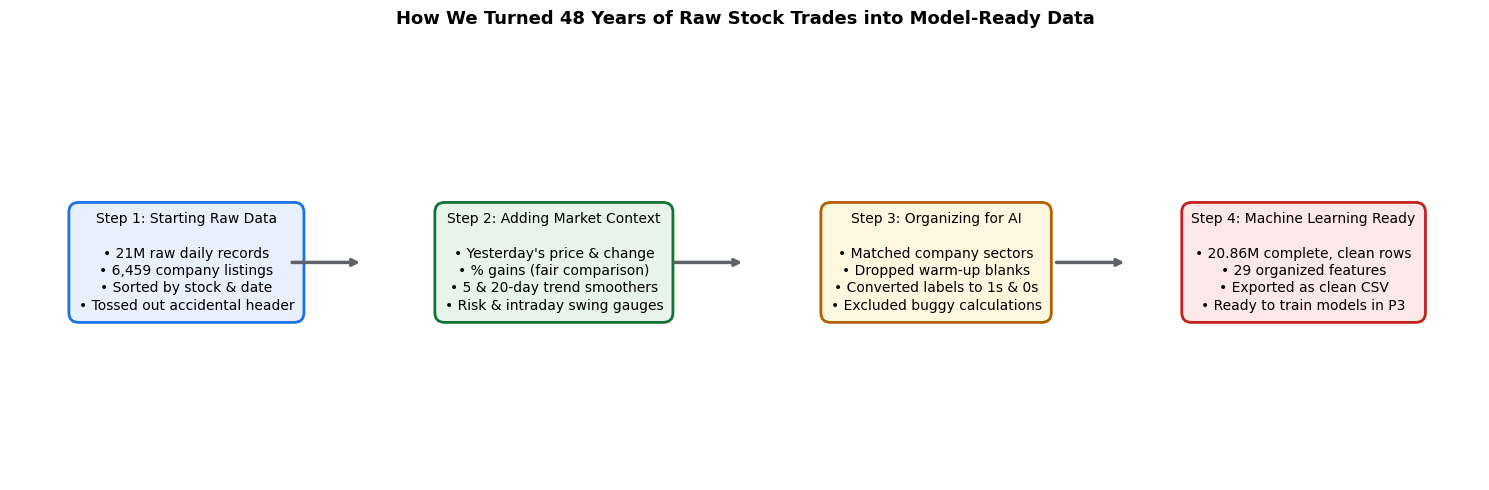

In [ ]:
### Step 3.5B: Visual Pipeline Diagram & Feature Snapshot (Python)

### This cell uses Matplotlib to generate a clean pipeline workflow diagram and a side-by-side snapshot of how our engineered features transformed a real stock (`AAPL`), giving you a visual to include in your technical report or notebook.


import matplotlib.pyplot as plt

# User-Friendly Visual Pipeline Flow
fig, ax = plt.subplots(figsize=(15, 5))
ax.axis('off')

# Visual Card Styles
box_raw = dict(boxstyle="round,pad=0.7", fc="#e8f0fe", ec="#1a73e8", lw=2)
box_feat = dict(boxstyle="round,pad=0.7", fc="#e6f4ea", ec="#137333", lw=2)
box_clean = dict(boxstyle="round,pad=0.7", fc="#fef7e0", ec="#b06000", lw=2)
box_final = dict(boxstyle="round,pad=0.7", fc="#fce8e6", ec="#c5221f", lw=2)

# Card 1: Raw Starting Point
text_step1 = (
    "Step 1: Starting Raw Data\n\n"
    "• 21M raw daily records\n"
    "• 6,459 company listings\n"
    "• Sorted by stock & date\n"
    "• Tossed out accidental header"
)

# Card 2: Building Real Context
text_step2 = (
    "Step 2: Adding Market Context\n\n"
    "• Yesterday's price & change\n"
    "• % gains (fair comparison)\n"
    "• 5 & 20-day trend smoothers\n"
    "• Risk & intraday swing gauges"
)

# Card 3: Tidying & Translating
text_step3 = (
    "Step 3: Organizing for AI\n\n"
    "• Matched company sectors\n"
    "• Dropped warm-up blanks\n"
    "• Converted labels to 1s & 0s\n"
    "• Excluded buggy calculations"
)

# Card 4: Final Ready State
text_step4 = (
    "Step 4: Machine Learning Ready\n\n"
    "• 20.86M complete, clean rows\n"
    "• 29 organized features\n"
    "• Exported as clean CSV\n"
    "• Ready to train models in P3"
)

# Place text boxes across the canvas
ax.text(0.12, 0.5, text_step1, ha="center", va="center", bbox=box_raw, fontsize=10, linespacing=1.3)
ax.text(0.37, 0.5, text_step2, ha="center", va="center", bbox=box_feat, fontsize=10, linespacing=1.3)
ax.text(0.63, 0.5, text_step3, ha="center", va="center", bbox=box_clean, fontsize=10, linespacing=1.3)
ax.text(0.88, 0.5, text_step4, ha="center", va="center", bbox=box_final, fontsize=10, linespacing=1.3)

# Connector Arrows
arrow = dict(arrowstyle="->", lw=2.5, color="#5f6368")
ax.annotate("", xy=(0.24, 0.5), xytext=(0.19, 0.5), arrowprops=arrow)
ax.annotate("", xy=(0.50, 0.5), xytext=(0.45, 0.5), arrowprops=arrow)
ax.annotate("", xy=(0.76, 0.5), xytext=(0.71, 0.5), arrowprops=arrow)

plt.title("How We Turned 48 Years of Raw Stock Trades into Model-Ready Data", fontsize=13, weight="bold", pad=15)
plt.tight_layout()
plt.show()

# Part 4 — Prepare the Final Dataset

### What We Are Doing
In this final phase, we organize, audit, and export our production-ready table:
1. **Column Ordering:** Structure our 29 features systematically: identifiers and dates first, core trade metrics second, engineered indicators third, and one-hot encoded metadata fourth.
2. **Quality Verification:** Run an integrity audit to verify that zero nulls remain, no duplicate trading days exist for any ticker, and data types are optimized.
3. **Export:** Save the finalized dataset as `stock_prepared.csv` directly into Google Drive for seamless pickup in Project 3.

---

### Variable Selection Rationale

* **Identifiers (`ticker`, `date`):** Essential for tracking individual corporate entities across time.
* **Core Price & Volume (`open`, `high`, `low`, `close`, `volume`):** Retained as fundamental market activity benchmarks. The problematic `adj_close` column was intentionally dropped to eliminate vendor overflow artifacts (such as `AAN`'s 18.9 quintillion USD glitch).
* **Momentum & Trend Features (`close_lag_1`, `price_change`, `daily_return`, `ma_5`, `ma_20`):** Provide predictive models with directional trajectory and smoothing, avoiding single-point tunnel vision.
* **Risk & Turbulence Indicators (`volatility_20`, `daily_range_pct`):** Supply normalized metrics for intraday price spread and historical return stability, enabling algorithms to account for risk regime shifts.
* **Structural Metadata (One-Hot Encoded Exchange & Sectors):** Enable models to detect systemic sector-wide behavior and exchange-specific liquidity patterns without imposing arbitrary numerical hierarchies.

In [ ]:
import os

print("=" * 60)
print("PART 4: FINAL INTEGRITY AUDIT & DATASET EXPORT")
print("=" * 60)

# 1. Structure and reorder the final feature set
base_cols = [
    'ticker', 'date', 'open', 'high', 'low', 'close', 'volume',
    'close_lag_1', 'price_change', 'daily_return',
    'ma_5', 'ma_20', 'volatility_20', 'daily_range_pct'
]
encoded_cols = sorted([c for c in df_prices.columns if c.startswith(('exchange_', 'sector_'))])
final_cols = base_cols + encoded_cols

df_final = df_prices[final_cols].copy()

# 2. Comprehensive Quality & Integrity Checks
print("\n--- Integrity Audit ---")
print(f"Total Rows              : {len(df_final):,}")
print(f"Total Columns           : {len(df_final.columns)}")
print(f"Temporal Range          : {df_final['date'].min().strftime('%Y-%m-%d')} to {df_final['date'].max().strftime('%Y-%m-%d')}")
print(f"Unique Tickers          : {df_final['ticker'].nunique():,}")

# Check for residual missing values
null_count = df_final.isna().sum().sum()
print(f"Total Missing Values    : {null_count}")

# Check for duplicate ticker + date combinations
duplicate_records = df_final.duplicated(subset=['ticker', 'date']).sum()
print(f"Duplicate (ticker, date): {duplicate_records}")

# Check data types breakdown
print("\nColumn Data Types:")
print(df_final.dtypes.value_counts())

# 3. Export prepared dataset to Google Drive
# Saves directly to your existing StockData folder
export_path = "/content/drive/MyDrive/StockData/stock_prepared.csv"

# Fallback path if StockData folder is not at that exact level
if not os.path.exists("/content/drive/MyDrive/StockData"):
    export_path = "/content/drive/MyDrive/stock_prepared.csv"

print(f"\nExporting finalized dataset to: {export_path}")
print("Writing CSV to Drive (this may take 2-4 minutes for ~20.8M rows)...")

df_final.to_csv(export_path, index=False)

print("Export complete! File successfully written to Google Drive.")
print(f"Final File Size: {os.path.getsize(export_path) / 1e9:.2f} GB")

PART 4: FINAL INTEGRITY AUDIT & DATASET EXPORT

--- Integrity Audit ---
Total Rows              : 20,860,334
Total Columns           : 29
Temporal Range          : 1970-01-30 to 2018-08-24
Unique Tickers          : 5,671
Total Missing Values    : 0
Duplicate (ticker, date): 0

Column Data Types:
int8              15
float32           12
datetime64[ns]     1
object             1
Name: count, dtype: int64

Exporting finalized dataset to: /content/drive/MyDrive/StockData/stock_prepared.csv
Writing CSV to Drive (this may take 2-4 minutes for ~20.8M rows)...
Export complete! File successfully written to Google Drive.
Final File Size: 3.06 GB


# Section 5 — Documentation and Findings Summary

### 1. What data-quality issues did you investigate?
* **Injected Header Row:** We detected and purged a duplicated table header (`['Symbol', 'NYSE', ...]`) at index 74 in `df_stocks` that was introduced during an upstream file concatenation.
* **Unclassified Assets (Missing Sectors):** We investigated 1,440 securities lacking sector and industry designations. Rather than discarding them—which would have created survivorship bias—we retained them under an explicit `'Unknown'` classification to protect non-operating entities like ETFs, trusts, and SPACs.
* **Corrupted Calculations (`adj_close`):** We audited floating-point calculation anomalies, specifically Aaron's Inc. (`AAN`), where an upstream divide-by-zero or split error produced an impossible adjusted close of 18.9 quintillion USD on February 27, 1987.
* **Lookback Cold-Starts:** We identified and audited the initial missing values generated by rolling time-series calculations across every ticker's opening weeks of trading.

---

### 2. What decisions did you make about unusual observations?
* **Multi-Million Dollar Closes (e.g., SCON, TOPS):** Retained. These extreme dollar figures are mathematically correct artifacts of repeated historical reverse stock splits (such as 1-for-50 consolidations) executed by micro-caps to avoid exchange delisting. To keep these large nominal prices from skewing models, we engineered normalized percentage features (`daily_return` and `daily_range_pct`).
* **The 18.9 Quintillion Overflow (AAN):** We preserved the trading record itself (as raw open, high, low, close, and volume are accurate), but completely excluded the `adj_close` column from our machine learning feature set.

---

### 3. What new features did you create?
All features were engineered strictly **grouped by ticker** across chronological dates:
* `close_lag_1`: Previous trading session's closing price.
* `price_change`: Net dollar move from the previous session (`close - close_lag_1`).
* `daily_return`: Percentage price change from the previous session (`close.pct_change(1)`).
* `ma_5`: 5-day rolling average of close (1-week price momentum).
* `ma_20`: 20-day rolling average of close (1-month baseline trend).
* `volatility_20`: 20-day rolling standard deviation of daily percentage returns.
* `daily_range_pct` (Additional Feature): Intraday price swing percentage:
  $$\frac{\text{high} - \text{low}}{\text{low}}$$

---

### 4. Which feature do you think may be useful for future analysis, and why?
**`daily_return` paired with `volatility_20`.**  
Raw stock prices are deceptive because a 1.00 USD price swing means something drastically different on a 5.00 USD stock (+20%) versus a 500.00 USD stock (+0.2%). `daily_return` strips away share-price bias and normalizes all 6,459 securities onto an identical scale. Paired with `volatility_20`, it gives machine learning models an immediate read on whether a stock is moving within a calm regime or experiencing severe risk and turbulence.

---

### 5. What does your final prepared dataset contain?
* **Total Records:** 20,860,334 clean, production-ready rows (spanning 1970–2018).
* **Total Features:** 29 columns.
  * *Identifiers & Core Market Data (7):* `ticker`, `date`, `open`, `high`, `low`, `close`, `volume`.
  * *Engineered Time-Series Indicators (7):* `close_lag_1`, `price_change`, `daily_return`, `ma_5`, `ma_20`, `volatility_20`, `daily_range_pct`.
  * *One-Hot Encoded Exchange Dimensions (2):* `exchange_NASDAQ`, `exchange_NYSE`.
  * *One-Hot Encoded Sector Dimensions (13):* 12 GICS economic sectors plus `sector_Unknown`.
* **Data Integrity:** Exactly 0 missing values, 0 duplicate (ticker, date) records, and 0 warm-up artifacts.

---

### 6. What additional information or features might be useful when building a predictive model?
* **Macroeconomic & Interest Rate Indicators:** Incorporating Federal Reserve benchmark interest rates, CPI inflation figures, and Treasury yield curve spreads (e.g., 10-Year minus 2-Year) to provide macroeconomic context.
* **Volume-Weighted Average Price (VWAP) & Relative Volume:** A feature comparing today's volume against a 30-day moving average volume to highlight institutional accumulation or distribution.
* **Market-Wide Index Baselines:** Adding daily returns for the S&P 500 or NASDAQ Composite to calculate a rolling stock Beta (measuring how much an individual security moves relative to the broader market).
* **Calendar & Cyclical Signals:** Month-of-year, day-of-week, and earnings-announcement proximity flags to capture recurring seasonal and calendar anomalies.

In [6]:

# Save active Colab runtime state, convert, and download HTML
import json
from google.colab import _message, files

notebook_json = _message.blocking_request('get_ipynb')
with open('/content/export.ipynb', 'w', encoding='utf-8') as f:
    json.dump(notebook_json['ipynb'], f)

!jupyter nbconvert --to html /content/export.ipynb
files.download('/content/export.html')


[NbConvertApp] Converting notebook /content/export.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 501243 bytes to /content/export.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>